## COL taxonomy plots - kingdom

In [1]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken")

In [3]:
taxa = read.csv('otu_id_kingdom.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,3379134,Pseudomonadati,K
2,1783272,Bacillati,K
3,4751,Fungi,K
4,3366610,Methanobacteriati,K
5,3384189,Fusobacteriati,K
6,1783275,Thermoproteati,K


In [4]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")
head(taxa)

,otuid,species
,<int>,<chr>
1,3379134,Pseudomonadati
2,1783272,Bacillati
3,4751,Fungi
4,3366610,Methanobacteriati
5,3384189,Fusobacteriati
6,1783275,Thermoproteati


In [5]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
3379134,Pseudomonadati
1783272,Bacillati
4751,Fungi
3366610,Methanobacteriati
3384189,Fusobacteriati
1783275,Thermoproteati


In [6]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy) 

 chr [1:15, 1] "Pseudomonadati" "Bacillati" "Fungi" "Methanobacteriati" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:15] "3379134" "1783272" "4751" "3366610" ...
  ..$ : chr "species"


In [7]:
#read in normalized otu table
otu = read.csv('otu_normtable_kingdom.csv',header=TRUE)
head(otu)

,X,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3379134,572009.024,612795.689,764659.727,712837.585,559782.712,717638.620,547701.849,709547.844,567843.131,⋯,598933.595,533125.437,507902.142,575063.164,668611.907,659115.430,580065.044,603809.817,545768.824,32056135.2
2,1783272,309692.727,290466.132,190257.975,238430.423,317232.463,221318.378,316788.510,250286.669,305077.774,⋯,284288.070,325460.480,342548.671,305902.541,252588.692,245370.547,299835.800,292144.177,328936.309,17561872.0
3,4751,81356.644,61368.151,29869.894,31888.133,85845.000,41272.917,95468.297,26316.845,88809.266,⋯,82849.826,96496.852,103945.328,77315.496,54242.758,66344.646,83449.686,71565.003,86385.944,4425403.1
4,3366610,14521.310,10692.777,4818.206,6189.532,14264.876,7512.297,12575.501,6751.420,13330.610,⋯,13933.420,16000.233,14167.576,10743.892,8470.255,10307.227,12536.415,12066.133,14384.100,693625.2
5,3384189,6377.484,9120.309,3326.501,2938.564,5929.490,3422.641,8021.189,1694.425,7322.048,⋯,5240.818,8889.018,10193.534,8379.083,4591.210,5564.908,6875.218,5627.439,7619.099,401550.4
6,1783275,4465.405,8779.608,1408.169,1470.909,4991.759,2904.680,6309.284,846.521,5259.619,⋯,4086.716,6108.650,8011.256,6203.905,3860.118,4210.506,5178.131,4107.620,4799.219,257092.3


In [8]:
# rename first col as kingdom
names(otu)[1] <- "species"
head(otu)
dim(otu)

,species,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_570_DLAB_S3,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3379134,572009.024,612795.689,764659.727,712837.585,559782.712,717638.620,547701.849,709547.844,567843.131,⋯,598933.595,533125.437,507902.142,575063.164,668611.907,659115.430,580065.044,603809.817,545768.824,32056135.2
2,1783272,309692.727,290466.132,190257.975,238430.423,317232.463,221318.378,316788.510,250286.669,305077.774,⋯,284288.070,325460.480,342548.671,305902.541,252588.692,245370.547,299835.800,292144.177,328936.309,17561872.0
3,4751,81356.644,61368.151,29869.894,31888.133,85845.000,41272.917,95468.297,26316.845,88809.266,⋯,82849.826,96496.852,103945.328,77315.496,54242.758,66344.646,83449.686,71565.003,86385.944,4425403.1
4,3366610,14521.310,10692.777,4818.206,6189.532,14264.876,7512.297,12575.501,6751.420,13330.610,⋯,13933.420,16000.233,14167.576,10743.892,8470.255,10307.227,12536.415,12066.133,14384.100,693625.2
5,3384189,6377.484,9120.309,3326.501,2938.564,5929.490,3422.641,8021.189,1694.425,7322.048,⋯,5240.818,8889.018,10193.534,8379.083,4591.210,5564.908,6875.218,5627.439,7619.099,401550.4
6,1783275,4465.405,8779.608,1408.169,1470.909,4991.759,2904.680,6309.284,846.521,5259.619,⋯,4086.716,6108.650,8011.256,6203.905,3860.118,4210.506,5178.131,4107.620,4799.219,257092.3


[1] 16 58

In [9]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,species,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3379134,572009.024,612795.689,764659.727,712837.585,559782.712,717638.620,547701.849,709547.844,567843.131,⋯,598933.595,533125.437,507902.142,575063.164,668611.907,659115.430,580065.044,603809.817,545768.824,32056135.2
2,1783272,309692.727,290466.132,190257.975,238430.423,317232.463,221318.378,316788.510,250286.669,305077.774,⋯,284288.070,325460.480,342548.671,305902.541,252588.692,245370.547,299835.800,292144.177,328936.309,17561872.0
3,4751,81356.644,61368.151,29869.894,31888.133,85845.000,41272.917,95468.297,26316.845,88809.266,⋯,82849.826,96496.852,103945.328,77315.496,54242.758,66344.646,83449.686,71565.003,86385.944,4425403.1
4,3366610,14521.310,10692.777,4818.206,6189.532,14264.876,7512.297,12575.501,6751.420,13330.610,⋯,13933.420,16000.233,14167.576,10743.892,8470.255,10307.227,12536.415,12066.133,14384.100,693625.2
5,3384189,6377.484,9120.309,3326.501,2938.564,5929.490,3422.641,8021.189,1694.425,7322.048,⋯,5240.818,8889.018,10193.534,8379.083,4591.210,5564.908,6875.218,5627.439,7619.099,401550.4
6,1783275,4465.405,8779.608,1408.169,1470.909,4991.759,2904.680,6309.284,846.521,5259.619,⋯,4086.716,6108.650,8011.256,6203.905,3860.118,4210.506,5178.131,4107.620,4799.219,257092.3


In [10]:
# make the index the otus
row.names(otu_table) <- otu_table$species
otu_table$species <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3379134,572009.024,612795.689,764659.727,712837.585,559782.712,717638.620,547701.849,709547.844,567843.131,565274.882,⋯,598933.595,533125.437,507902.142,575063.164,668611.907,659115.430,580065.044,603809.817,545768.824,32056135.2
1783272,309692.727,290466.132,190257.975,238430.423,317232.463,221318.378,316788.510,250286.669,305077.774,315243.867,⋯,284288.070,325460.480,342548.671,305902.541,252588.692,245370.547,299835.800,292144.177,328936.309,17561872.0
4751,81356.644,61368.151,29869.894,31888.133,85845.000,41272.917,95468.297,26316.845,88809.266,83703.746,⋯,82849.826,96496.852,103945.328,77315.496,54242.758,66344.646,83449.686,71565.003,86385.944,4425403.1
3366610,14521.310,10692.777,4818.206,6189.532,14264.876,7512.297,12575.501,6751.420,13330.610,12508.813,⋯,13933.420,16000.233,14167.576,10743.892,8470.255,10307.227,12536.415,12066.133,14384.100,693625.2
3384189,6377.484,9120.309,3326.501,2938.564,5929.490,3422.641,8021.189,1694.425,7322.048,6547.913,⋯,5240.818,8889.018,10193.534,8379.083,4591.210,5564.908,6875.218,5627.439,7619.099,401550.4
1783275,4465.405,8779.608,1408.169,1470.909,4991.759,2904.680,6309.284,846.521,5259.619,6448.060,⋯,4086.716,6108.650,8011.256,6203.905,3860.118,4210.506,5178.131,4107.620,4799.219,257092.3


In [11]:
#remove Sum column
otu_table$Sum <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3379134,572009.024,612795.689,764659.727,712837.585,559782.712,717638.620,547701.849,709547.844,567843.131,565274.882,⋯,727421.701,598933.595,533125.437,507902.142,575063.164,668611.907,659115.430,580065.044,603809.817,545768.824
1783272,309692.727,290466.132,190257.975,238430.423,317232.463,221318.378,316788.510,250286.669,305077.774,315243.867,⋯,222054.642,284288.070,325460.480,342548.671,305902.541,252588.692,245370.547,299835.800,292144.177,328936.309
4751,81356.644,61368.151,29869.894,31888.133,85845.000,41272.917,95468.297,26316.845,88809.266,83703.746,⋯,32079.548,82849.826,96496.852,103945.328,77315.496,54242.758,66344.646,83449.686,71565.003,86385.944
3366610,14521.310,10692.777,4818.206,6189.532,14264.876,7512.297,12575.501,6751.420,13330.610,12508.813,⋯,6988.498,13933.420,16000.233,14167.576,10743.892,8470.255,10307.227,12536.415,12066.133,14384.100
3384189,6377.484,9120.309,3326.501,2938.564,5929.490,3422.641,8021.189,1694.425,7322.048,6547.913,⋯,3910.642,5240.818,8889.018,10193.534,8379.083,4591.210,5564.908,6875.218,5627.439,7619.099
1783275,4465.405,8779.608,1408.169,1470.909,4991.759,2904.680,6309.284,846.521,5259.619,6448.060,⋯,1730.814,4086.716,6108.650,8011.256,6203.905,3860.118,4210.506,5178.131,4107.620,4799.219


In [12]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3379134,572009.024,612795.689,764659.727,712837.585,559782.71,717638.620,547701.849,709547.844,567843.131,565274.882,⋯,727421.701,598933.595,533125.437,507902.14,575063.164,668611.907,659115.430,580065.044,603809.817,545768.824
1783272,309692.727,290466.132,190257.975,238430.423,317232.46,221318.378,316788.510,250286.669,305077.774,315243.867,⋯,222054.642,284288.070,325460.480,342548.67,305902.541,252588.692,245370.547,299835.800,292144.177,328936.309
Total_reads,171541.000,190783.000,335187.000,307293.000,211148.00,536720.000,92879.000,722959.000,352497.000,330487.000,⋯,260571.000,285070.000,171560.000,174130.00,537887.000,845311.000,522740.000,471985.000,97380.000,73762.000
4751,81356.644,61368.151,29869.894,31888.133,85845.00,41272.917,95468.297,26316.845,88809.266,83703.746,⋯,32079.548,82849.826,96496.852,103945.33,77315.496,54242.758,66344.646,83449.686,71565.003,86385.944
3366610,14521.310,10692.777,4818.206,6189.532,14264.88,7512.297,12575.501,6751.420,13330.610,12508.813,⋯,6988.498,13933.420,16000.233,14167.58,10743.892,8470.255,10307.227,12536.415,12066.133,14384.100
3384189,6377.484,9120.309,3326.501,2938.564,5929.49,3422.641,8021.189,1694.425,7322.048,6547.913,⋯,3910.642,5240.818,8889.018,10193.53,8379.083,4591.210,5564.908,6875.218,5627.439,7619.099


In [13]:
#remove total reads row
otus_sorted <- otus_sorted[-3, ]
head(otus_sorted)
dim (otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3379134,572009.024,612795.689,764659.727,712837.585,559782.712,717638.620,547701.849,709547.844,567843.131,565274.882,⋯,727421.701,598933.595,533125.437,507902.142,575063.164,668611.907,659115.430,580065.044,603809.817,545768.824
1783272,309692.727,290466.132,190257.975,238430.423,317232.463,221318.378,316788.510,250286.669,305077.774,315243.867,⋯,222054.642,284288.070,325460.480,342548.671,305902.541,252588.692,245370.547,299835.800,292144.177,328936.309
4751,81356.644,61368.151,29869.894,31888.133,85845.000,41272.917,95468.297,26316.845,88809.266,83703.746,⋯,32079.548,82849.826,96496.852,103945.328,77315.496,54242.758,66344.646,83449.686,71565.003,86385.944
3366610,14521.310,10692.777,4818.206,6189.532,14264.876,7512.297,12575.501,6751.420,13330.610,12508.813,⋯,6988.498,13933.420,16000.233,14167.576,10743.892,8470.255,10307.227,12536.415,12066.133,14384.100
3384189,6377.484,9120.309,3326.501,2938.564,5929.490,3422.641,8021.189,1694.425,7322.048,6547.913,⋯,3910.642,5240.818,8889.018,10193.534,8379.083,4591.210,5564.908,6875.218,5627.439,7619.099
1783275,4465.405,8779.608,1408.169,1470.909,4991.759,2904.680,6309.284,846.521,5259.619,6448.060,⋯,1730.814,4086.716,6108.650,8011.256,6203.905,3860.118,4210.506,5178.131,4107.620,4799.219


[1] 15 56

In [14]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
3379134,572009.024,612795.689,764659.727,712837.585,559782.712,717638.620,547701.849,709547.844,567843.131,565274.882,⋯,727421.701,598933.595,533125.437,507902.142,575063.164,668611.907,659115.430,580065.044,603809.817,545768.824
1783272,309692.727,290466.132,190257.975,238430.423,317232.463,221318.378,316788.510,250286.669,305077.774,315243.867,⋯,222054.642,284288.070,325460.480,342548.671,305902.541,252588.692,245370.547,299835.800,292144.177,328936.309
4751,81356.644,61368.151,29869.894,31888.133,85845.000,41272.917,95468.297,26316.845,88809.266,83703.746,⋯,32079.548,82849.826,96496.852,103945.328,77315.496,54242.758,66344.646,83449.686,71565.003,86385.944
3366610,14521.310,10692.777,4818.206,6189.532,14264.876,7512.297,12575.501,6751.420,13330.610,12508.813,⋯,6988.498,13933.420,16000.233,14167.576,10743.892,8470.255,10307.227,12536.415,12066.133,14384.100
3384189,6377.484,9120.309,3326.501,2938.564,5929.490,3422.641,8021.189,1694.425,7322.048,6547.913,⋯,3910.642,5240.818,8889.018,10193.534,8379.083,4591.210,5564.908,6875.218,5627.439,7619.099
1783275,4465.405,8779.608,1408.169,1470.909,4991.759,2904.680,6309.284,846.521,5259.619,6448.060,⋯,1730.814,4086.716,6108.650,8011.256,6203.905,3860.118,4210.506,5178.131,4107.620,4799.219


In [15]:
#read in metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken/COL_metadata_012025.csv', header=TRUE)
head(metadata)

,SampleID,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
2,032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
3,032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
4,032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
5,032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
6,012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,


In [16]:
# index the SampleIDs
row.names(metadata) <- metadata$SampleID
metadata$SampleID <- NULL
head(metadata)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
032024_COL_SAN_T5_139_OFAV_S17,ELARBOL,3/7/24,Mar_2024,21,OFAV,Healthy,Healthy,,Y-2026,Healthy_Treatment
032024_COL_SAN_T5_140_OFAV_S18c,ELARBOL,3/7/24,Mar_2024,22,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_141_OFAV_S19,ELARBOL,3/7/24,Mar_2024,23,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_166_OFAV_S20,ELARBOL,3/7/24,Mar_2024,29,OFAV,Healthy,Healthy,,,
032024_COL_SAN_T5_167_OFAV_S21,ELARBOL,3/7/24,Mar_2024,37,OFAV,Healthy,Healthy,,,
012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan_2025,37,OFAV,Healthy,Healthy,Y-2025,,


In [17]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(metadata)

In [18]:
# Create phyloseq object
COL_k_all = phyloseq(OTU, SAMP, TAX)
COL_k_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 15 taxa and 56 samples ]
sample_data() Sample Data:       [ 56 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 15 taxa by 1 taxonomic ranks ]

In [19]:
#order of facets - might not need because want to facet by species
sample_data(COL_k_all)$Species_o <- factor(sample_data(COL_k_all)$Species, 
                                      levels = c("OFAV", "MCAV", "DLAB", "PSTR"))

In [20]:
options(repr.plot.width=15, repr.plot.height=15)

In [21]:
#install.packages("viridis")
#install.packages("pals")

In [22]:
library(viridis)
library(pals)

Loading required package: viridisLite


Attaching package: ‘pals’


The following objects are masked from ‘package:viridis’:

    cividis, inferno, magma, plasma, turbo, viridis


The following objects are masked from ‘package:viridisLite’:

    cividis, inferno, magma, plasma, turbo, viridis




Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


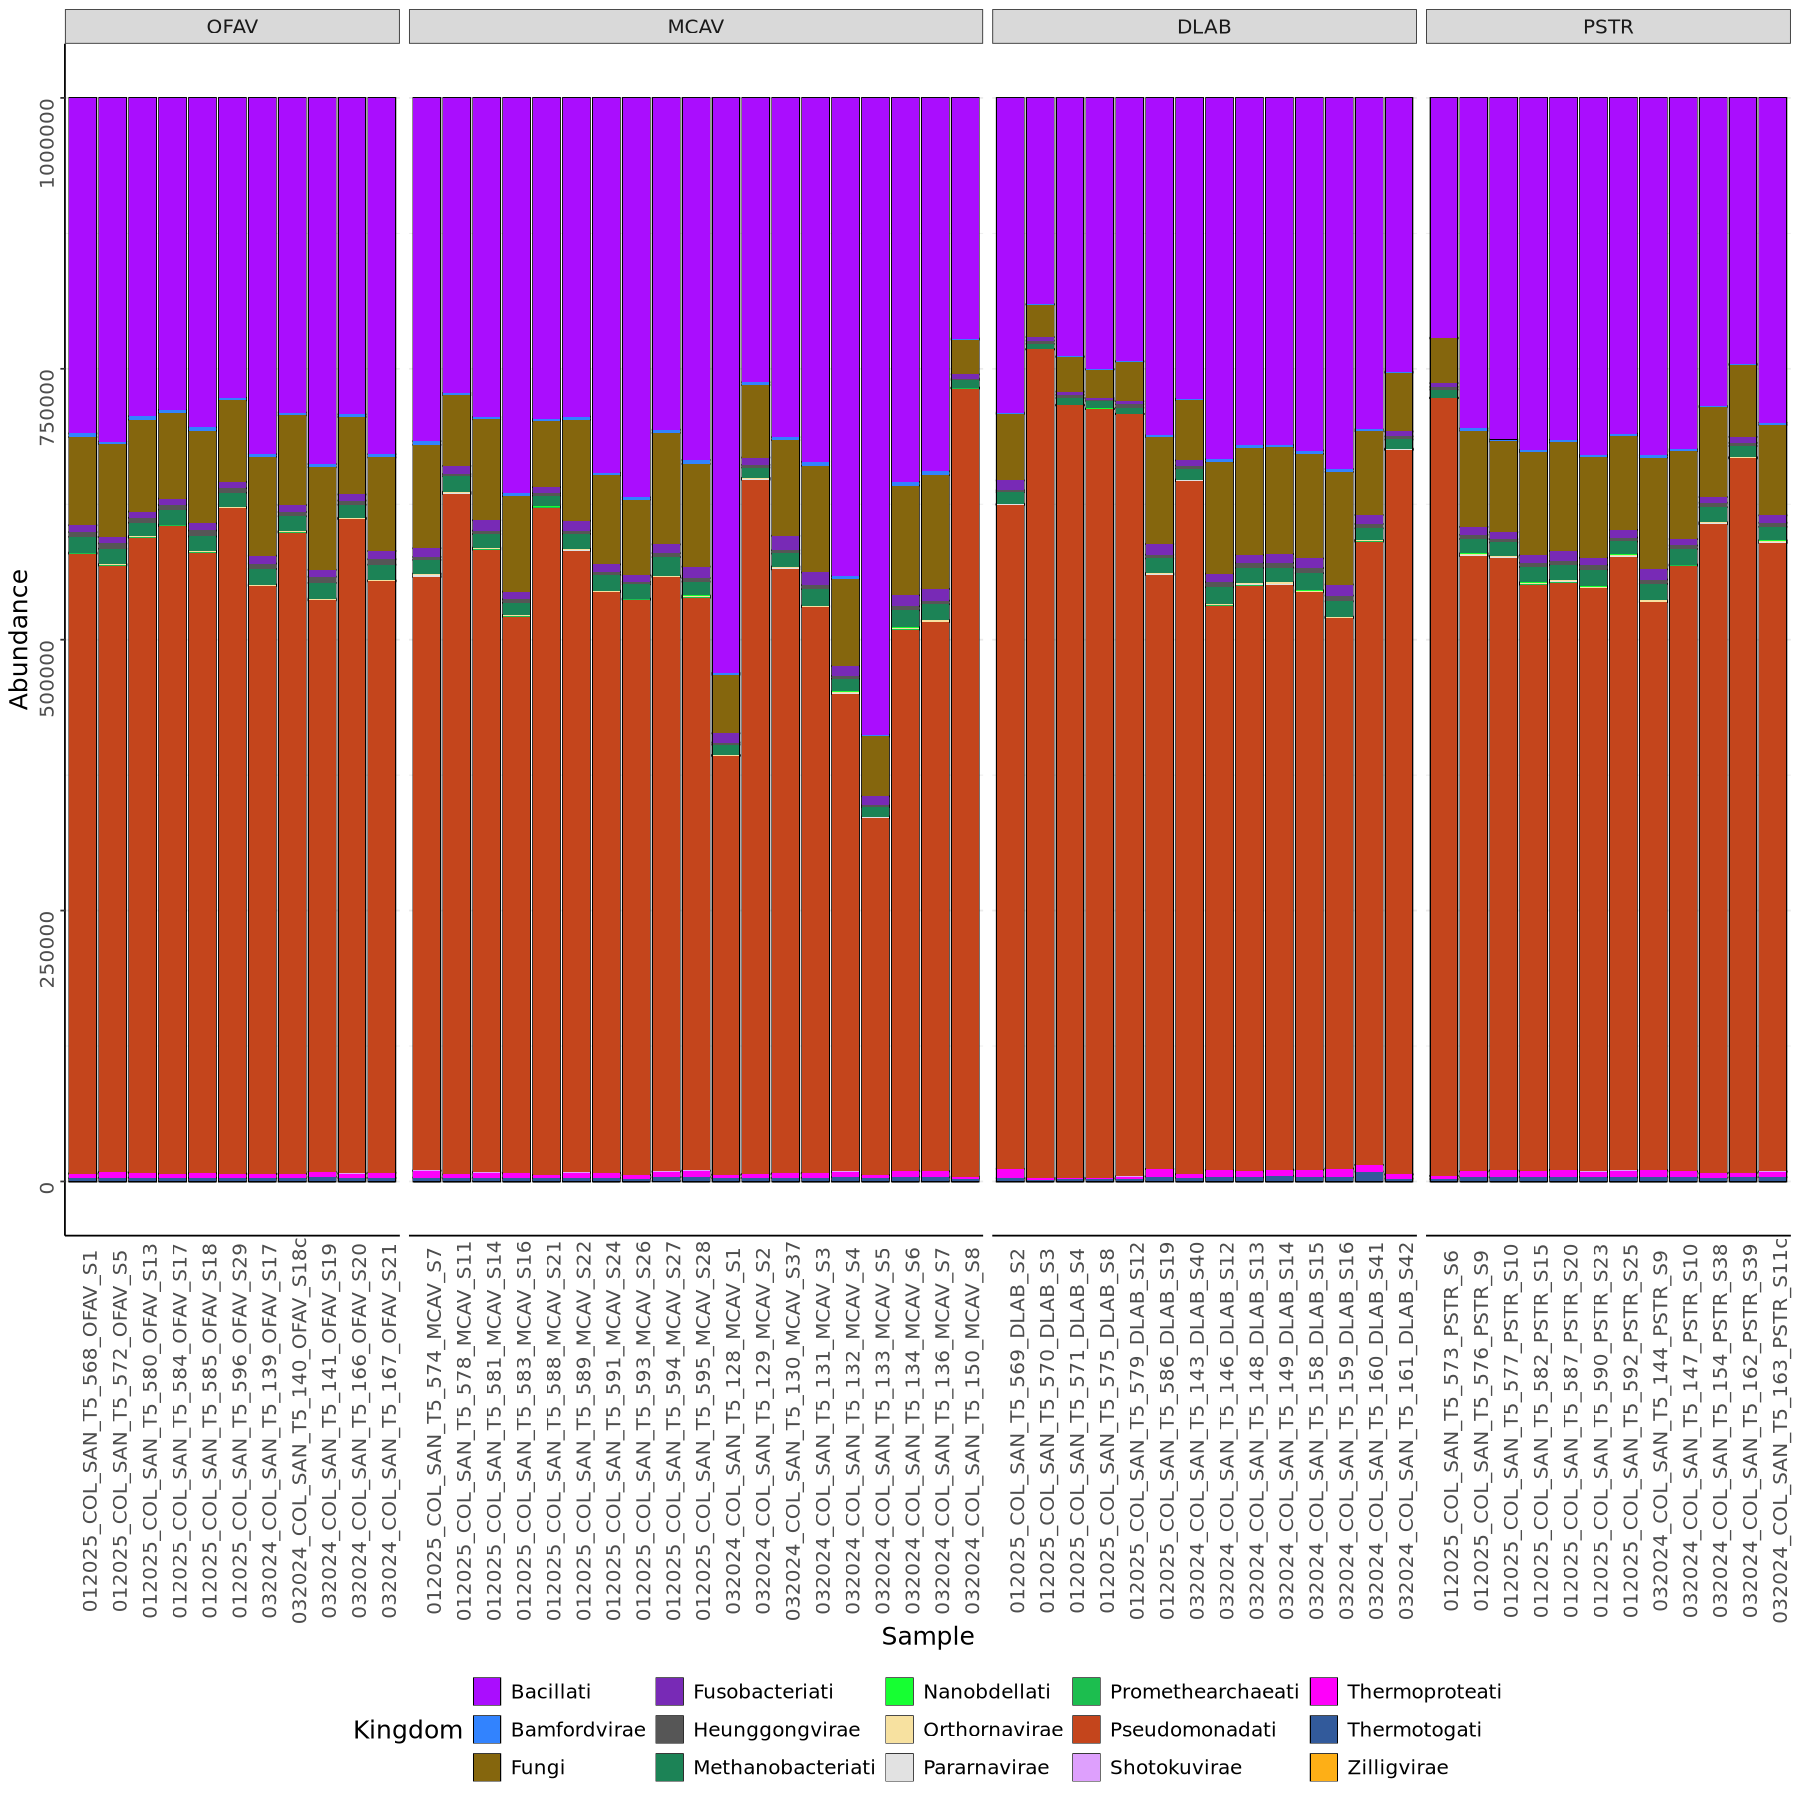

In [23]:
# bar plot of kingdoms IDed in all samples
COL_k_all_bar<-plot_bar(COL_k_all,fill='species')+
facet_grid(~Species_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values=unname(alphabet2())) +
theme_bw()+
labs(fill = "Kingdom")+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
COL_k_all_bar

In [24]:
#save with the hideous colors for now but find new palette pronto
ggsave(filename = "taxonomy_kingdoms.png", plot = COL_k_all_bar, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 100)